   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOc

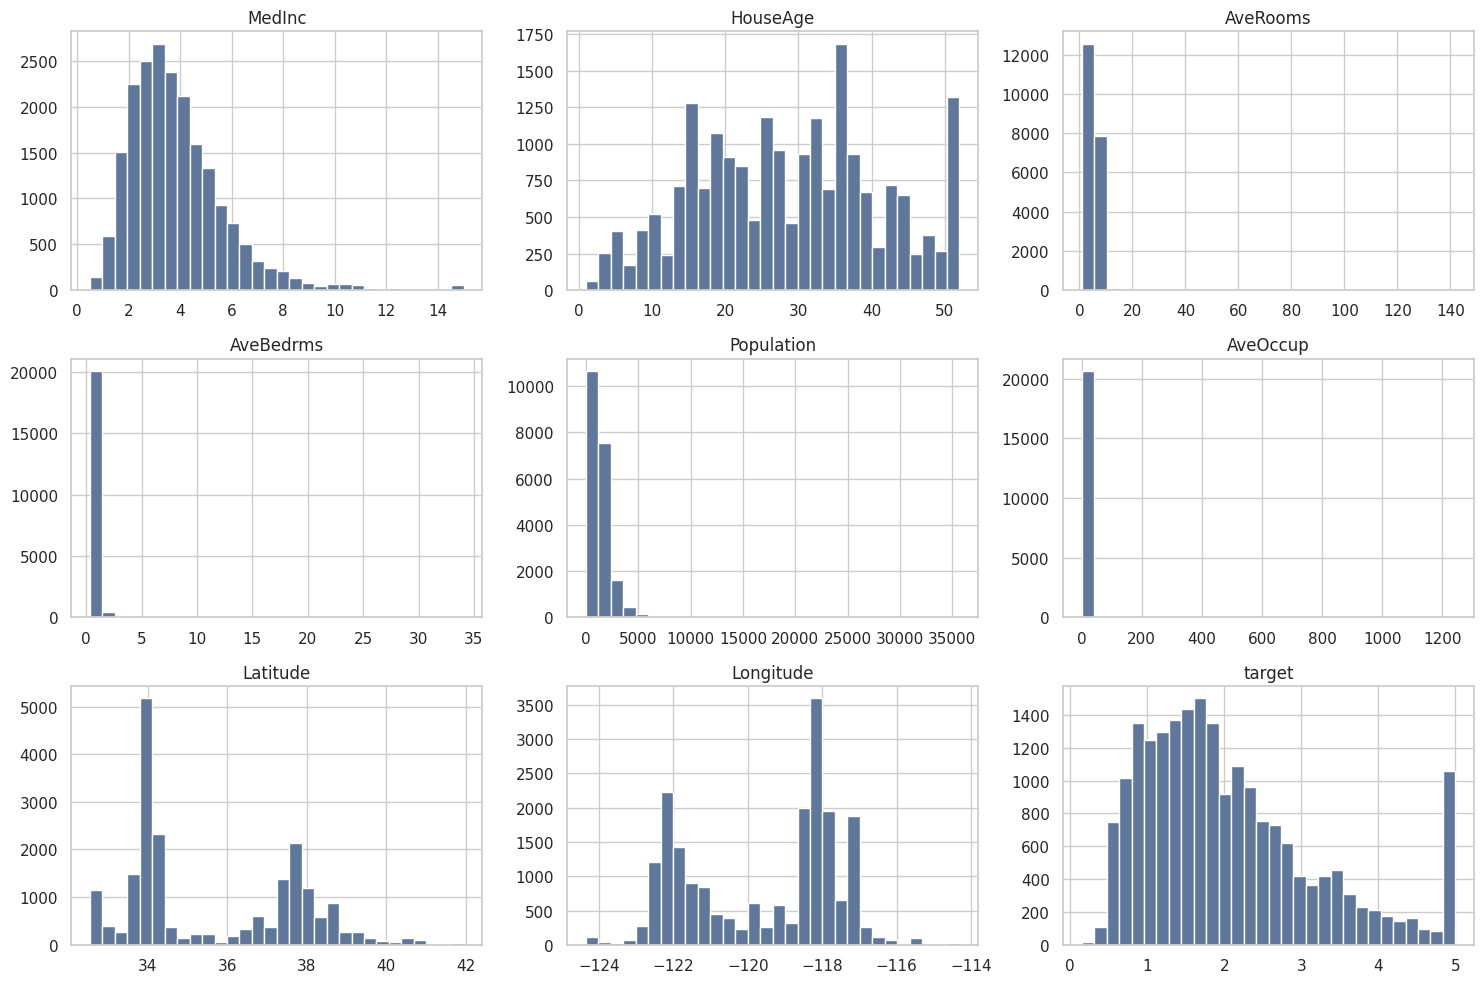

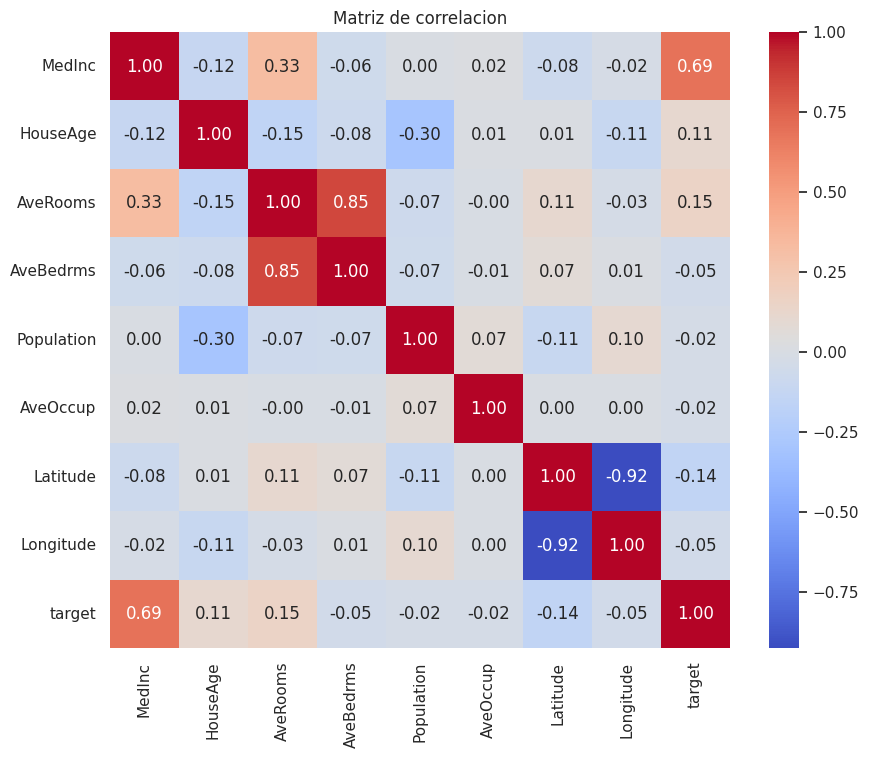

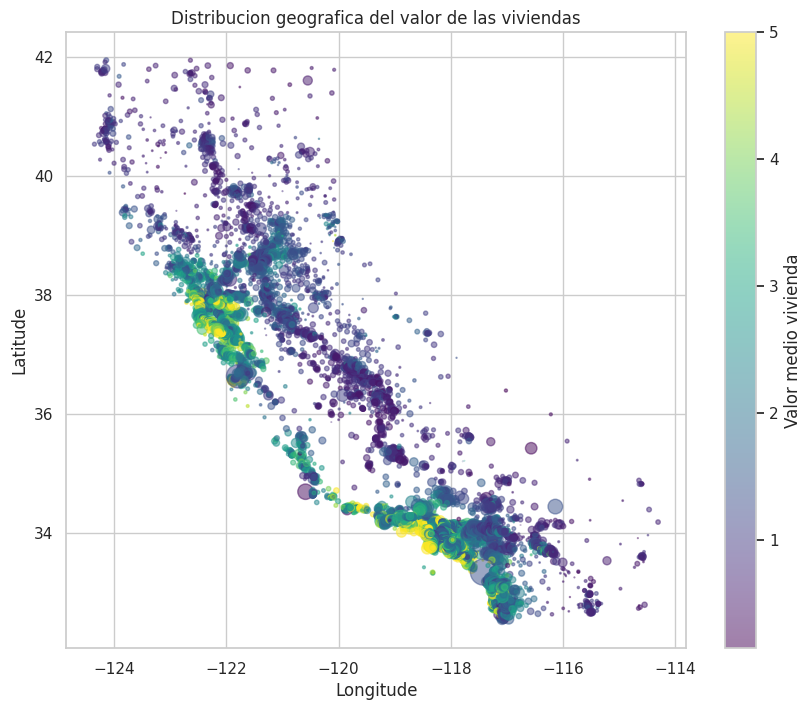

Registros con target truncado (5.00001): 965
Train: (15740, 8) Test: (3935, 8)
                      modelo     mae     mse    rmse     mape   smape  \
3      RandomForestRegressor  0.3146  0.2233  0.4726  18.2433  0.3086   
4  GradientBoostingRegressor  0.3521  0.2486  0.4986  21.0648  0.3480   
2        KNeighborsRegressor  0.4297  0.3757  0.6130  24.3461  0.3916   
1                      Ridge  0.4898  0.4239  0.6511  30.6625  0.4693   
0           LinearRegression  0.4898  0.4239  0.6511  30.6619  0.4693   

   tiempo_seg  
3     20.8869  
4      5.2644  
2      0.0363  
1      0.0043  
0      0.0077  


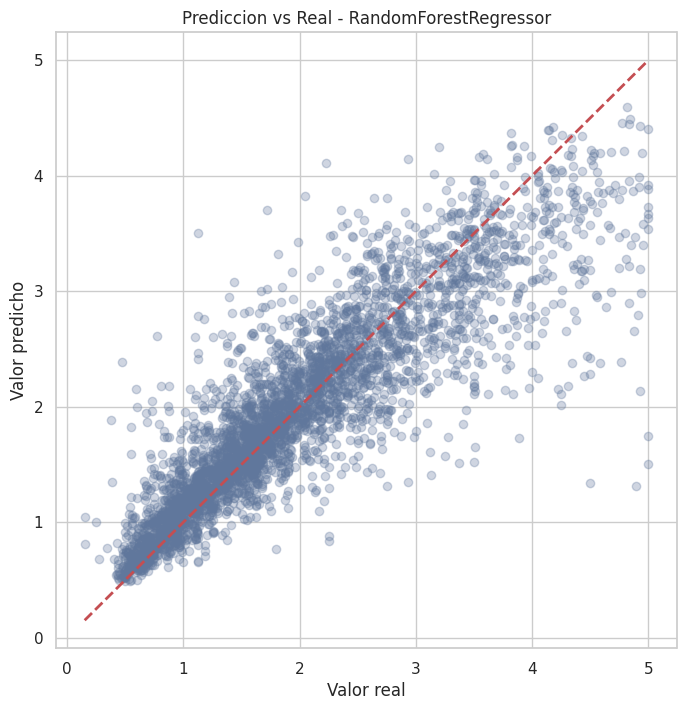

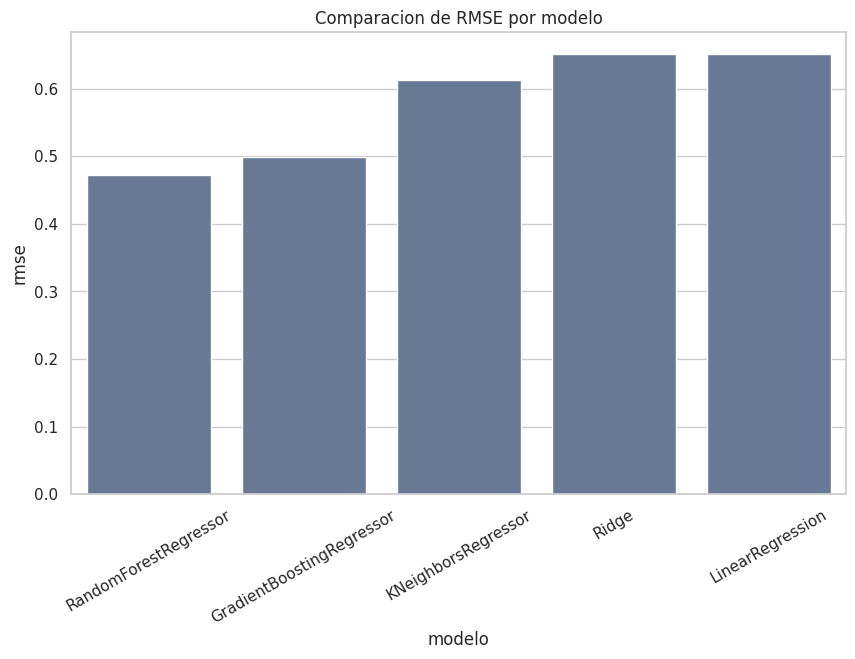

El modelo con menor RMSE fue: RandomForestRegressor


In [51]:
# REGRESION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import time

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def regression_metrics(df):
    df_result = pd.DataFrame()
    y_true = df['y']
    y_pred = df['yhat']
    df_result['mae'] = [round(mean_absolute_error(y_true, y_pred), 4)]
    df_result['mse'] = [round(mean_squared_error(y_true, y_pred), 4)]
    df_result['rmse'] = [round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)]
    df_result['mape'] = [round(mean_absolute_percentage_error(y_true, y_pred), 4)]
    df_result['smape'] = [round(2 * mean_absolute_percentage_error(y_true, y_pred) / (mean_absolute_percentage_error(y_true, y_pred) + 100), 4)]
    return df_result

# Carga de datos
from sklearn.datasets import fetch_california_housing
housing_data = fetch_california_housing(as_frame=True)
housing = housing_data['data']
housing['target'] = housing_data['target']
print(housing.head())

# 1) Definicion del problema
# Objetivo: predecir el valor medio de vivienda (target) en distritos de
# California a partir de variables socioeconomicas y geograficas. Regresion supervisada.

# 2) Estadistica descriptiva
print(housing.info())
print(housing.describe())
print("Nulos:\n", housing.isnull().sum())
print("Duplicados:", housing.duplicated().sum())
print("Correlacion con target:\n", housing.corr()['target'].sort_values(ascending=False))

# 3) Visualizacion descriptiva
housing.hist(bins=30, figsize=(15, 10)); plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(housing.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlacion'); plt.show()

plt.figure(figsize=(10, 8))
sc = plt.scatter(housing['Longitude'], housing['Latitude'], c=housing['target'],
                  cmap='viridis', alpha=0.5, s=housing['Population']/100)
plt.colorbar(sc, label='Valor medio vivienda')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title('Distribucion geografica del valor de las viviendas'); plt.show()

# 4) Preprocesamiento
print("Registros con target truncado (5.00001):", (housing['target'] == 5.00001).sum())
housing_clean = housing[housing['target'] < 5.00001].copy()

X = housing_clean.drop(columns='target')
y = housing_clean['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5) Seleccion de modelo (al menos 4)
modelos = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "KNeighborsRegressor": KNeighborsRegressor(n_neighbors=5),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42)
}

# 6) Metricas y analisis de resultados
resultados = []
predicciones = {}
for nombre, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_train_scaled, y_train)
    tiempo_entrenamiento = time.time() - inicio
    y_pred = modelo.predict(X_test_scaled)
    predicciones[nombre] = y_pred
    df_temp = pd.DataFrame({'y': y_test.values, 'yhat': y_pred})
    metrics = regression_metrics(df_temp)
    metrics['modelo'] = nombre
    metrics['tiempo_seg'] = round(tiempo_entrenamiento, 4)
    resultados.append(metrics)

df_resultados = pd.concat(resultados, ignore_index=True)
df_resultados = df_resultados[['modelo', 'mae', 'mse', 'rmse', 'mape', 'smape', 'tiempo_seg']]
print(df_resultados.sort_values('rmse'))

mejor_modelo = df_resultados.sort_values('rmse').iloc[0]['modelo']
mejor_pred = predicciones[mejor_modelo]

# 7) Visualizacion de resultados
plt.figure(figsize=(8, 8))
plt.scatter(y_test, mejor_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valor real'); plt.ylabel('Valor predicho')
plt.title(f'Prediccion vs Real - {mejor_modelo}'); plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='modelo', y='rmse', data=df_resultados.sort_values('rmse'))
plt.xticks(rotation=30); plt.title('Comparacion de RMSE por modelo'); plt.show()

# 8) Conclusiones
print(f"El modelo con menor RMSE fue: {mejor_modelo}")
# El ingreso medio (MedInc) es la variable mas correlacionada con el valor de la vivienda.
# Los modelos de ensamble (RandomForest, GradientBoosting) logran mejor RMSE que la
# regresion lineal simple, a costa de mayor tiempo de entrenamiento.

   c00  c01  c02  c03  c04  c05  c06  c07  c08  c09  ...  c55  c56  c57  c58  \
0    0    0    5   13    9    1    0    0    0    0  ...    0    0    0    6   
1    0    0    0   12   13    5    0    0    0    0  ...    0    0    0    0   
2    0    0    0    4   15   12    0    0    0    0  ...    0    0    0    0   
3    0    0    7   15   13    1    0    0    0    8  ...    0    0    0    7   
4    0    0    0    1   11    0    0    0    0    0  ...    0    0    0    0   

   c59  c60  c61  c62  c63  target  
0   13   10    0    0    0       0  
1   11   16   10    0    0       1  
2    3   11   16    9    0       2  
3   13   13    9    0    0       3  
4    2   16    4    0    0       4  

[5 rows x 65 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   c00     1797 non-null   int64
 1   c01     1797 non-null   int64
 2   c02     1797 non-null 

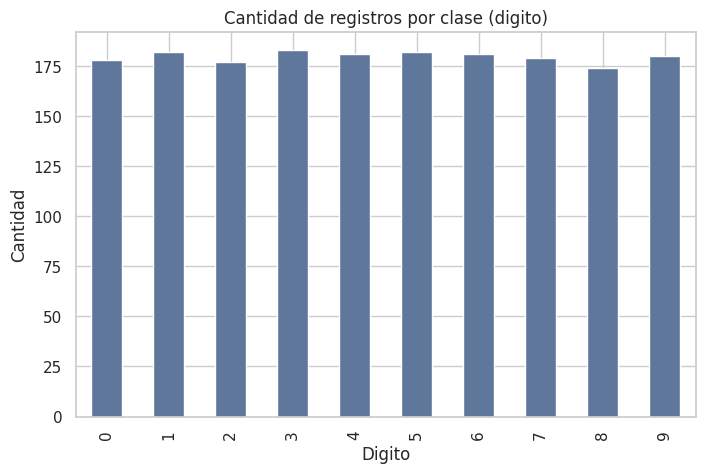

          c00          c01          c02          c03          c04  \
count  1797.0  1797.000000  1797.000000  1797.000000  1797.000000   
mean      0.0     0.303840     5.204786    11.835838    11.848080   
std       0.0     0.907192     4.754826     4.248842     4.287388   
min       0.0     0.000000     0.000000     0.000000     0.000000   
25%       0.0     0.000000     1.000000    10.000000    10.000000   
50%       0.0     0.000000     4.000000    13.000000    13.000000   
75%       0.0     0.000000     9.000000    15.000000    15.000000   
max       0.0     8.000000    16.000000    16.000000    16.000000   

               c05          c06          c07          c08          c09  ...  \
count  1797.000000  1797.000000  1797.000000  1797.000000  1797.000000  ...   
mean      5.781859     1.362270     0.129661     0.005565     1.993879  ...   
std       5.666418     3.325775     1.037383     0.094222     3.196160  ...   
min       0.000000     0.000000     0.000000     0.000000     

In [52]:
# ============================================================
# EJERCICIO 1: Analisis exploratorio
# ============================================================
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt

digits_dict = datasets.load_digits()

digits = (
    pd.DataFrame(digits_dict["data"])
    .rename(columns=lambda x: f"c{x:02d}")
    .assign(target=digits_dict["target"])
    .astype(int)
)

print(digits.head())

# Distribucion, tipos de dato y memoria
digits.info(memory_usage='deep')
print("\nUso de memoria total (MB):", digits.memory_usage(deep=True).sum() / 1024**2)
print(digits.dtypes.value_counts())

# Registros por clase
print(digits['target'].value_counts().sort_index())
plt.figure(figsize=(8, 5))
digits['target'].value_counts().sort_index().plot(kind='bar')
plt.title('Cantidad de registros por clase (digito)')
plt.xlabel('Digito'); plt.ylabel('Cantidad'); plt.show()

# Estadistica descriptiva y coherencia con lo esperado
print(digits.drop(columns='target').describe())
print("Nulos:", digits.isnull().sum().sum())
print("Rango de pixeles: min =", digits.drop(columns='target').values.min(),
      "max =", digits.drop(columns='target').values.max())
# Nota: los pixeles van de 0 a 16 (no 0-255 como sugiere el enunciado general),
# las clases estan balanceadas (~180 registros por digito) y no hay nulos.

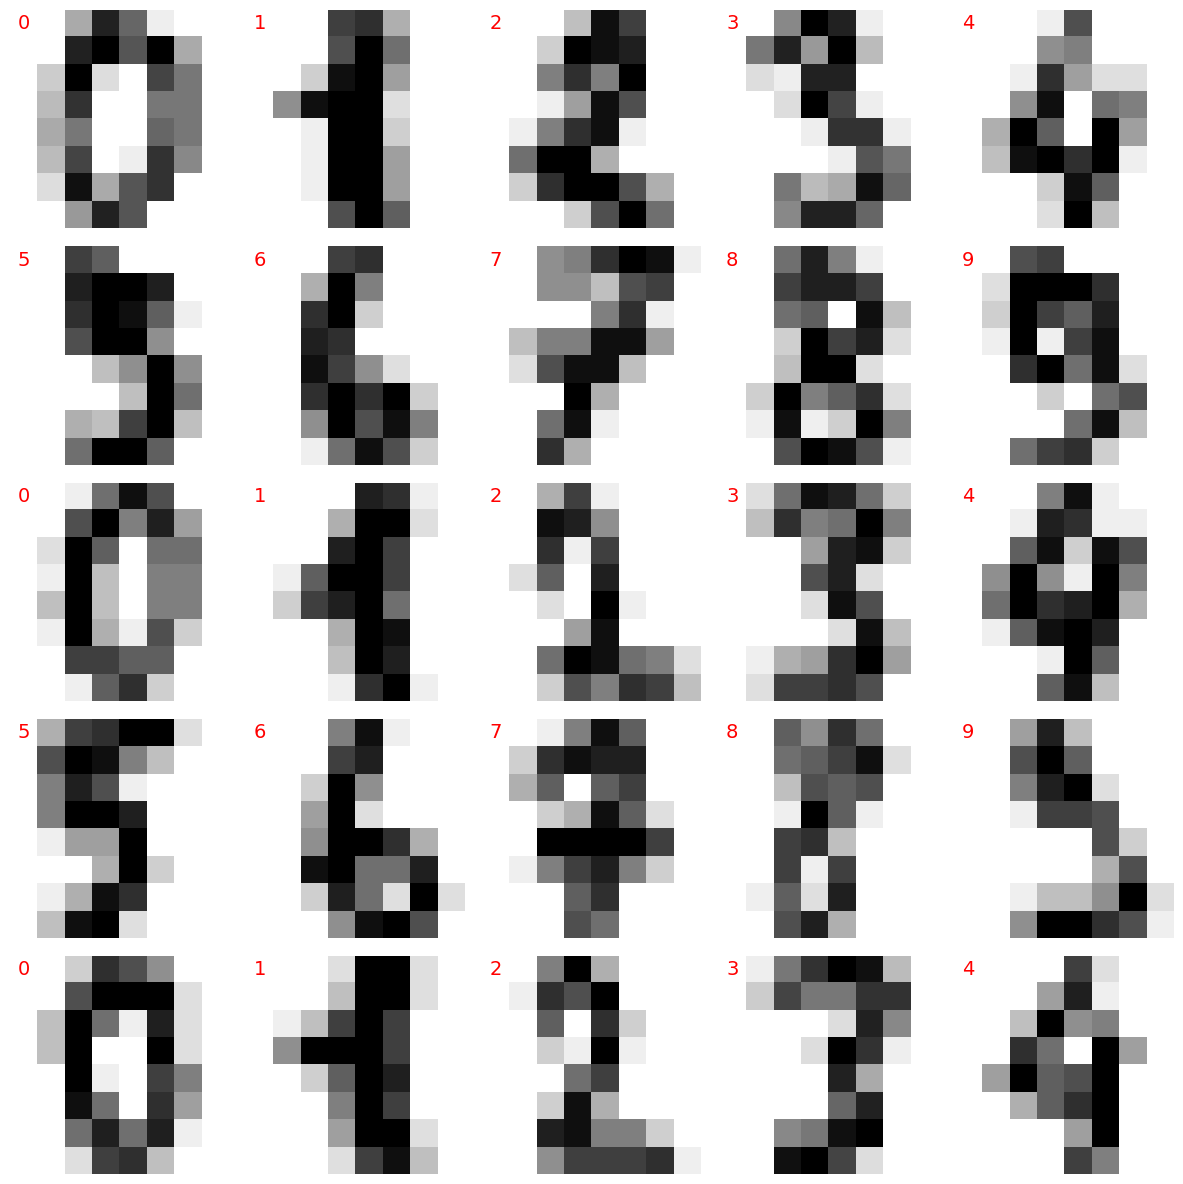

In [53]:
# ============================================================
# EJERCICIO 2: Visualizacion
# ============================================================
import matplotlib.pyplot as plt

nx, ny = 5, 5
fig, axs = plt.subplots(nx, ny, figsize=(12, 12))

for i, ax in enumerate(axs.flat):
    ax.imshow(digits_dict["images"][i], cmap='gray_r')
    ax.text(0, 0, str(digits_dict["target"][i]), color='red', fontsize=14,
            horizontalalignment='center', verticalalignment='center')
    ax.axis('off')

plt.tight_layout()
plt.show()

Largo conjunto de entrenamiento: 1437
Largo conjunto de testeo: 360
               modelo   score  accuracy  precision  recall  f1_score  \
1          KNeighbors  0.9861    0.9861     0.9879  0.9878    0.9878   
0  LogisticRegression  0.9750    0.9750     0.9767  0.9765    0.9765   
2        RandomForest  0.9722    0.9722     0.9740  0.9727    0.9732   

   tiempo_seg  
1      0.0010  
0      1.3692  
2      0.6632  


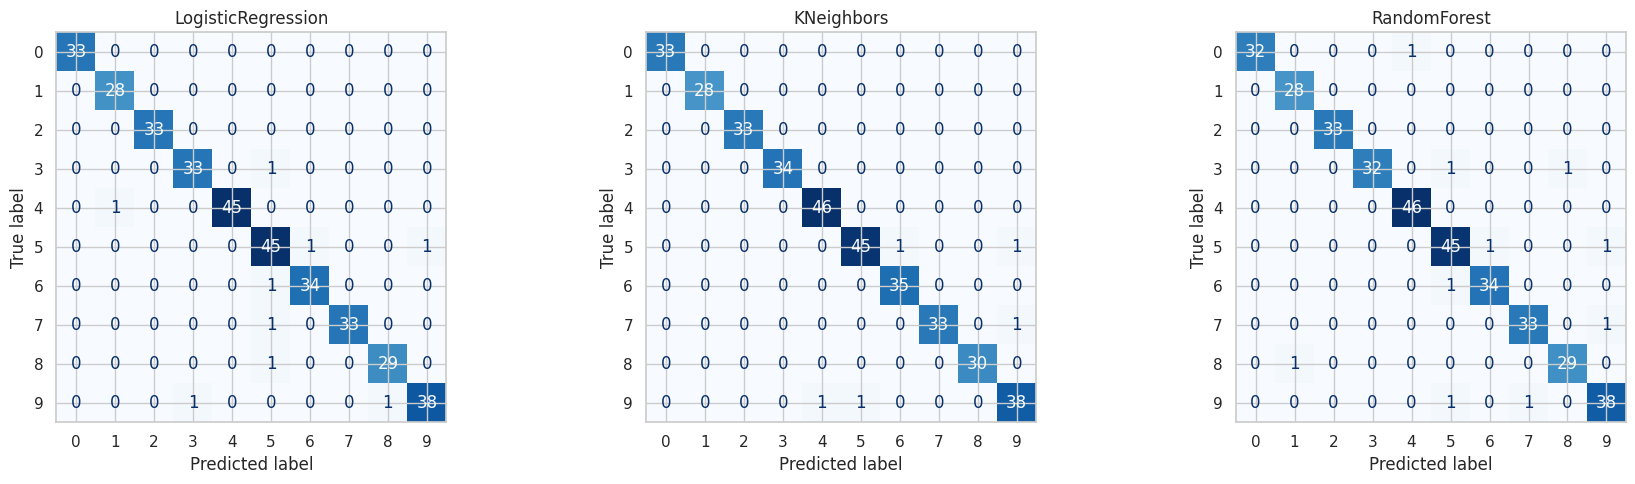

Mejor modelo elegido: KNeighbors


In [54]:
# ============================================================
# EJERCICIO 3: Machine Learning
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score, precision_score, recall_score, f1_score)
import time

# features, target
X = digits.drop(columns="target").values
y = digits["target"].values

# train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Largo conjunto de entrenamiento:", len(X_train))
print("Largo conjunto de testeo:", len(X_test))

# modelos
modelos_clf = {
    "LogisticRegression": LogisticRegression(max_iter=5000),
    "KNeighbors": KNeighborsClassifier(n_neighbors=5),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42)
}

resultados_clf = []
predicciones_clf = {}
modelos_entrenados = {}

for nombre, modelo in modelos_clf.items():
    inicio = time.time()
    modelo.fit(X_train, y_train)
    tiempo = time.time() - inicio
    y_pred = modelo.predict(X_test)
    predicciones_clf[nombre] = y_pred
    modelos_entrenados[nombre] = modelo
    resultados_clf.append({
        "modelo": nombre,
        "score": round(modelo.score(X_test, y_test), 4),
        "accuracy": round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred, average='macro'), 4),
        "recall": round(recall_score(y_test, y_pred, average='macro'), 4),
        "f1_score": round(f1_score(y_test, y_pred, average='macro'), 4),
        "tiempo_seg": round(tiempo, 4)
    })

df_resultados_clf = pd.DataFrame(resultados_clf)
print(df_resultados_clf.sort_values('f1_score', ascending=False))

# matriz de confusion
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nombre, y_pred) in zip(axs, predicciones_clf.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre)
plt.tight_layout(); plt.show()

# Preguntas:
# ¿Cual modelo es mejor segun sus metricas? -> el de mayor f1_score/accuracy en la tabla.
# ¿Cual demora menos en ajustarse? -> revisar columna tiempo_seg.
# ¿Que modelo escoges? -> el de mejor balance entre desempeño y tiempo de entrenamiento.
mejor_modelo_nombre = df_resultados_clf.sort_values('f1_score', ascending=False).iloc[0]['modelo']
mejor_modelo_clf = modelos_entrenados[mejor_modelo_nombre]
print("Mejor modelo elegido:", mejor_modelo_nombre)

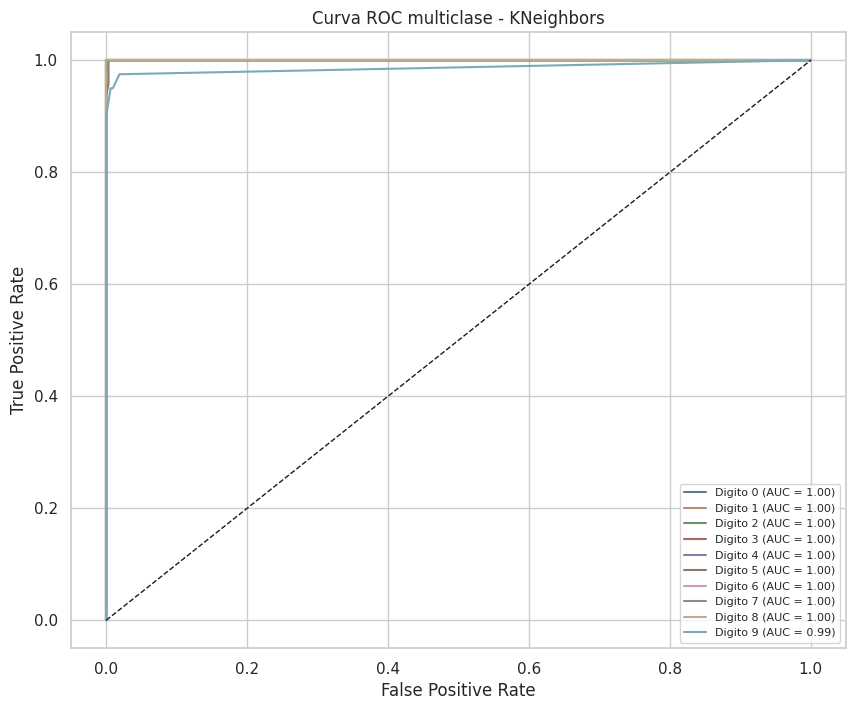

AUC promedio: 0.9987


In [55]:
# ============================================================
# EJERCICIO 4: Comprension del modelo (Curva AUC-ROC)
# ============================================================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

y_test_bin = label_binarize(y_test, classes=range(10))
y_score = mejor_modelo_clf.predict_proba(X_test)

fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f'Digito {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title(f'Curva ROC multiclase - {mejor_modelo_nombre}')
plt.legend(loc='lower right', fontsize=8)
plt.show()

print("AUC promedio:", round(np.mean(list(roc_auc.values())), 4))
# Conclusion: AUC cercano a 1 en todas las clases indica que el modelo
# distingue muy bien entre los distintos digitos.

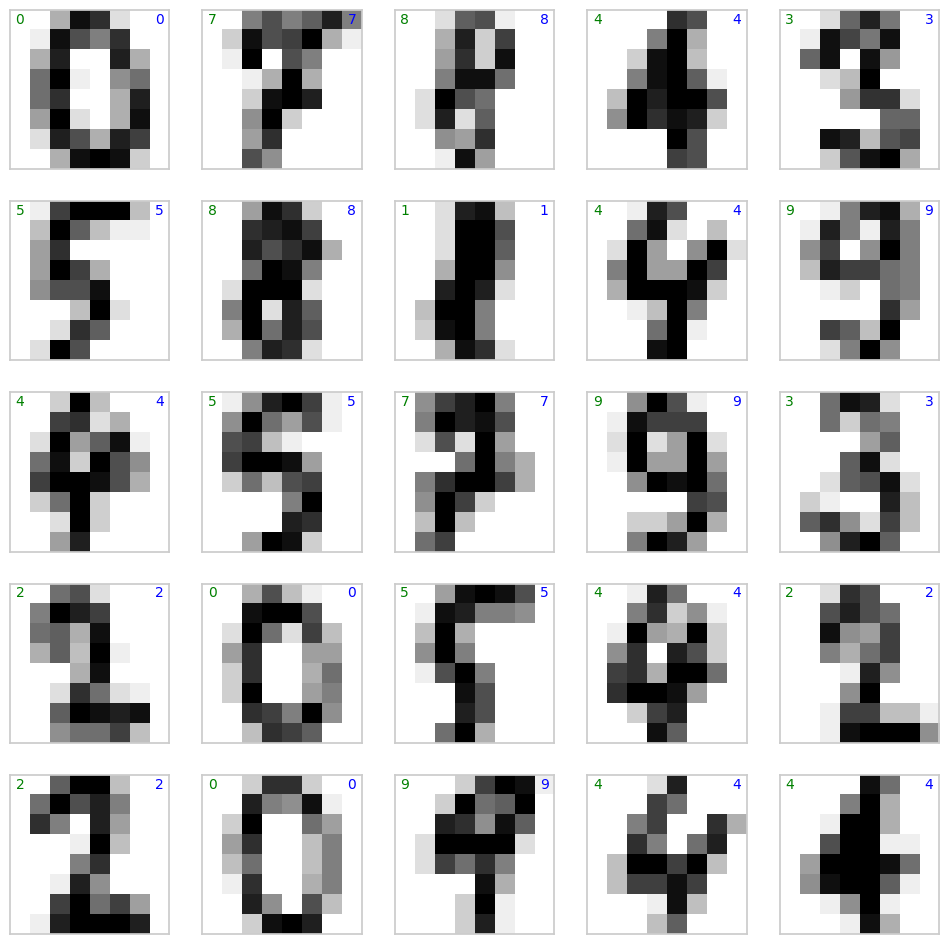

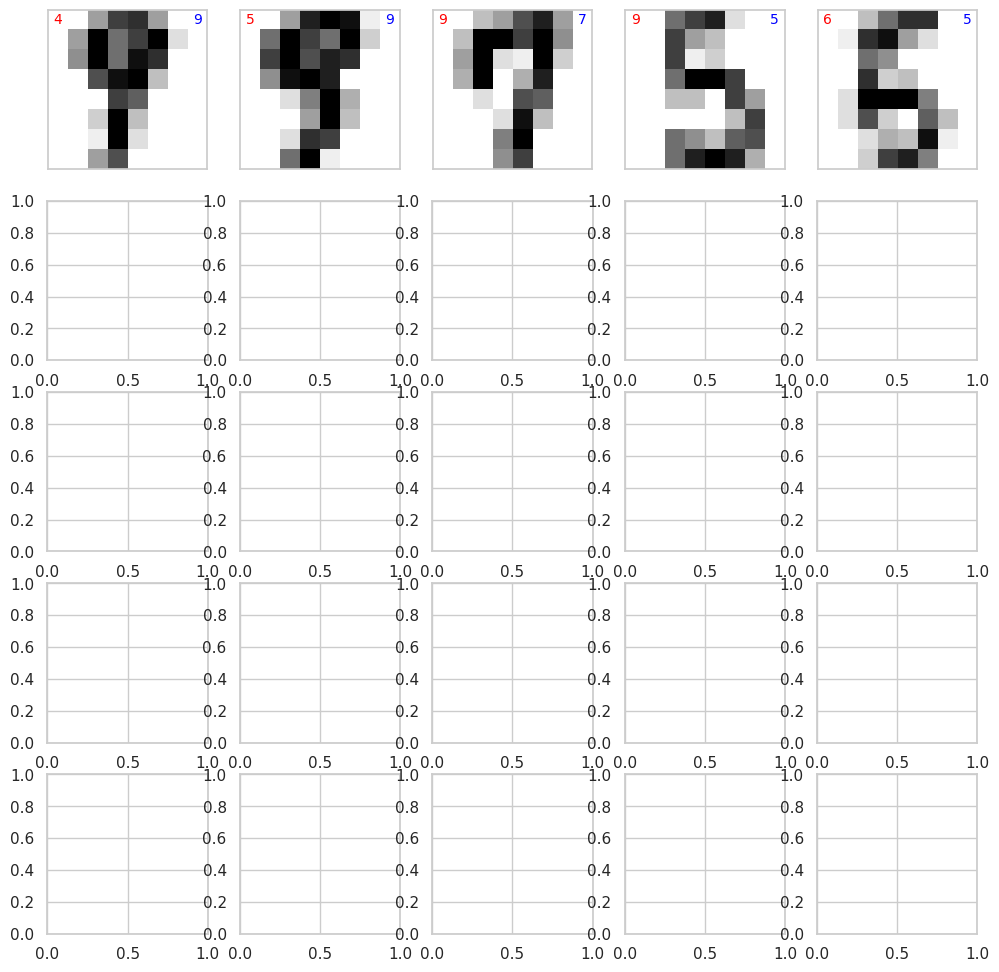

In [56]:
# ============================================================
# EJERCICIO 5: Visualizando Resultados
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def mostrar_resultados(digits, model, nx=5, ny=5, label="correctos"):
    """
    Muestra los resultados de las predicciones de un modelo de clasificación en particular.
    Se toman aleatoriamente los valores de los resultados.

    - label == 'correctos': muestra los valores en los que el modelo acierta.
    - label == 'incorrectos': muestra los valores en los que el modelo no acierta.

    Observación: El modelo que se recibe como argumento no debe estar entrenado.
    """
    X = digits.drop(columns="target").values
    y = digits["target"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if label == "correctos":
        mask = (y_pred == y_test)
        color = "green"
    elif label == "incorrectos":
        mask = (y_pred != y_test)
        color = "red"
    else:
        raise ValueError("Valor incorrecto")

    X_aux = X_test[mask]
    y_aux_true = y_test[mask]
    y_aux_pred = y_pred[mask]

    n_samples = min(nx * ny, len(X_aux))
    indices = np.random.choice(len(X_aux), n_samples, replace=False)
    fig, ax = plt.subplots(nx, ny, figsize=(12, 12))

    for i, index in enumerate(indices):
        data = X_aux[index, :].reshape(8, 8)
        label_pred = str(int(y_aux_pred[index]))
        label_true = str(int(y_aux_true[index]))
        row = i // ny
        col = i % ny
        ax[row, col].imshow(data, interpolation='nearest', cmap='gray_r')
        ax[row, col].text(0, 0, label_pred, horizontalalignment='center', verticalalignment='center', fontsize=10, color=color)
        ax[row, col].text(7, 0, label_true, horizontalalignment='center', verticalalignment='center', fontsize=10, color='blue')
        ax[row, col].get_xaxis().set_visible(False)
        ax[row, col].get_yaxis().set_visible(False)

    plt.show()

# Casos correctos
mostrar_resultados(digits, mejor_modelo_clf, nx=5, ny=5, label="correctos")

# Casos incorrectos
mostrar_resultados(digits, mejor_modelo_clf, nx=5, ny=5, label="incorrectos")
# ¿Por que ocurren estas fallas?
# Suelen darse en digitos visualmente similares (ej. 4 vs 9, 3 vs 8, 1 vs 7),
# debido a la baja resolucion de las imagenes (8x8 pixeles), que dificulta
# distinguir trazos parecidos entre ciertos digitos.

In [57]:
# ============================================================
# EJERCICIO 6: Conclusiones
# ============================================================
print("Mejor modelo encontrado:", mejor_modelo_nombre)
print(df_resultados_clf.sort_values('f1_score', ascending=False))

# - Los tres modelos (Logistic Regression, KNN, Random Forest) lograron un
#   desempeño alto en el dataset digits, dado que es un problema simple y balanceado.
# - El mejor modelo segun las metricas fue el indicado arriba.
# - La curva ROC confirma que el modelo distingue muy bien entre clases (AUC cercano a 1).
# - Los errores de clasificacion se concentran en digitos visualmente similares entre si.
# - Trabajo futuro: probar SVM o redes neuronales, aplicar PCA para visualizar mejor
#   la separacion entre clases, y aumentar la resolucion de las imagenes.

Mejor modelo encontrado: KNeighbors
               modelo   score  accuracy  precision  recall  f1_score  \
1          KNeighbors  0.9861    0.9861     0.9879  0.9878    0.9878   
0  LogisticRegression  0.9750    0.9750     0.9767  0.9765    0.9765   
2        RandomForest  0.9722    0.9722     0.9740  0.9727    0.9732   

   tiempo_seg  
1      0.0010  
0      1.3692  
2      0.6632  
